In [1]:
%matplotlib inline

import os, random, time, sys, warnings, copy
from timeit import default_timer as timer
from datetime import timedelta
from datetime import datetime
import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy import signal
import pandas as pd
import bct
from tqdm import tqdm

import neurogym as ngym
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from src.neural_network import RNN, run_training, run_testing
from src.utils import normalize_x, build_reg_ken, compute_rlfp, fix_labels, get_weight_masks, get_weight_masks_schaefer, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='DejaVu Sans')
import seaborn as sns
from src.plotting import my_reg_plot, plot_activity, plot_iodata

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# from torch.nn import init
# from torch.nn import functional as F
# import math

class CTRNN(nn.Module):
    """Continuous-time RNN.

    Args:
        input_size: Number of input neurons
        hidden_size: Number of hidden neurons

    Inputs:
        input: (seq_len, batch, input_size), network input
        hidden: (batch, hidden_size), initial hidden activity
    """

    def __init__(self, input_size, hidden_size, dt=None, **kwargs):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.tau = 100
        if dt is None:
            alpha = 1
        else:
            alpha = dt / self.tau
        self.alpha = alpha
        self.oneminusalpha = 1 - alpha

        self.input2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)

    def init_hidden(self, input_shape):
        batch_size = input_shape[1]
        return torch.zeros(batch_size, self.hidden_size)

    def recurrence(self, input, hidden):
        """Recurrence helper."""
        pre_activation = self.input2h(input) + self.h2h(hidden)
        h_new = torch.relu(hidden * self.oneminusalpha +
                           pre_activation * self.alpha)
        return h_new

    def forward(self, input, hidden=None):
        """Propogate input through the network."""
        if hidden is None:
            hidden = self.init_hidden(input.shape).to(input.device)

        output = []
        steps = range(input.size(0))
        for i in steps:
            hidden = self.recurrence(input[i], hidden)
            output.append(hidden)

        output = torch.stack(output, dim=0)
        return output, hidden


class RNNNet(nn.Module):
    """Recurrent network model.

    Args:
        input_size: int, input size
        hidden_size: int, hidden size
        output_size: int, output size
        rnn: str, type of RNN, lstm, rnn, ctrnn, or eirnn
    """
    def __init__(self, input_size, hidden_size, num_classes, regularization_kernel=None, input_weight_mask=None, output_weight_mask=None, **kwargs):
        super(RNNNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # Continuous time RNN
        self.rnn = CTRNN(input_size, hidden_size, **kwargs)
        self.fc = nn.Linear(hidden_size, num_classes)

        if regularization_kernel is not None:
            regularization_kernel = torch.from_numpy(regularization_kernel).type(torch.float)
            self.register_buffer('regularization_kernel', regularization_kernel)
        else:
            self.regularization_kernel = regularization_kernel

        if input_weight_mask is not None:
            if input_weight_mask.ndim == 1:
                input_weight_mask = np.repeat(input_weight_mask[:, np.newaxis], repeats=self.input_size, axis=1)
            input_weight_mask = torch.from_numpy(input_weight_mask).type(torch.float)
            self.register_buffer('input_weight_mask', input_weight_mask)
        else:
            self.input_weight_mask = input_weight_mask

        if output_weight_mask is not None:
            if output_weight_mask.ndim == 1:
                output_weight_mask = np.repeat(output_weight_mask[np.newaxis, :], repeats=self.num_classes, axis=0)
            output_weight_mask = torch.from_numpy(output_weight_mask).type(torch.float)
            self.register_buffer('output_weight_mask', output_weight_mask)
        else:
            self.output_weight_mask = output_weight_mask

    def regularization(self, w, type='l1', matrix=None):
        if type == 'l1' and matrix is None:
            return torch.abs(w).sum()
        elif type == 'l1' and matrix is not None:
            return torch.mul(torch.abs(w), matrix).sum()
        elif type == 'l2' and matrix is None:
            return torch.square(w).sum()
        elif type == 'l2' and matrix is not None:
            return torch.mul(torch.square(w), matrix).sum()

    def forward(self, x):
        with torch.no_grad():
            if self.input_weight_mask is not None:
                self.rnn.input2h.weight.mul_(self.input_weight_mask)
            if self.output_weight_mask is not None:
                self.fc.weight.mul_(self.output_weight_mask)

        rnn_activity, _ = self.rnn(x)
        out = self.fc(rnn_activity)
        return out, rnn_activity

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'
# task = 'MultiSensoryIntegration-v0'
# task = 'ContextDecisionMaking-v0'
dt = 100
batch_size = 32
decision = 300
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 5

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 25
n_epochs = 30000
lr = 0.001

# regularization parameters
kernel_type = 'sa_axis'
# kernel_type = 'euclidean'
# kernel_type = None
reg_type = 'l2'
reg_weight = 0.0015
mask_weights = True

print(seq_len, reg_weight)

120 0.0015


In [5]:
if task == 'ContextDecisionMaking-v0':
    timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
else:
    timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}
# env_kwargs = {'dt': dt}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'kernel_type': kernel_type, 'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs
}

3 3
(120, 32, 3) (120, 32)


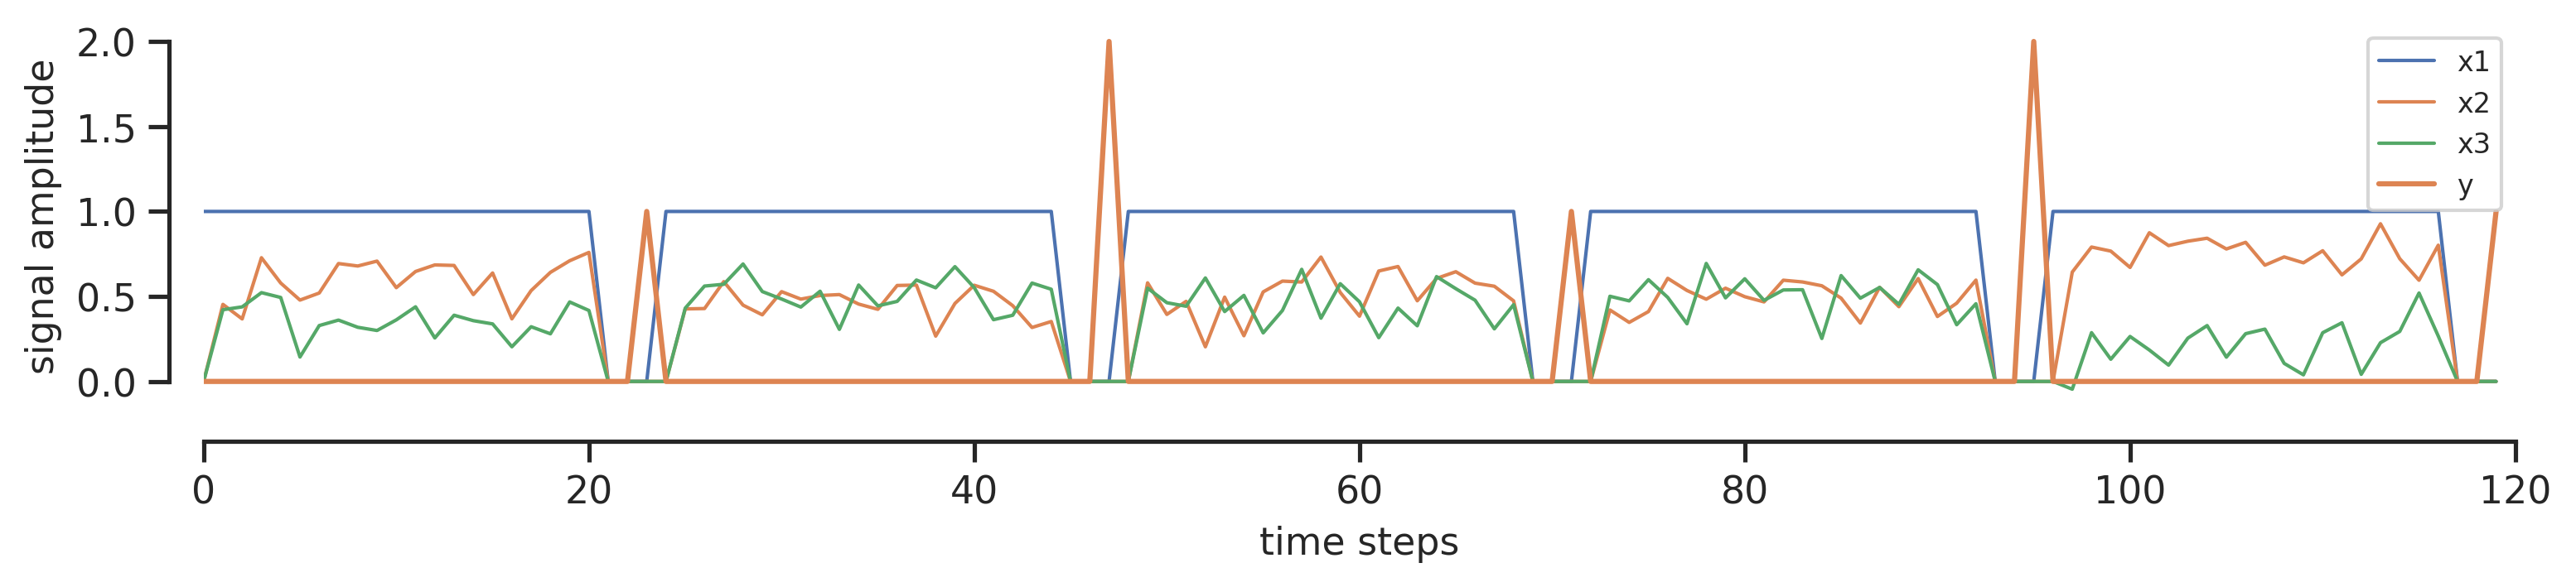

In [6]:
# Environment
# Make supervised dataset
dataset = ngym.Dataset(config['task'], env_kwargs=env_kwargs, batch_size=config['batch_size'], seq_len=config['seq_len'])
dataset.env.reset(seed=0)
input_size = dataset.env.observation_space.shape[0]
num_classes = dataset.env.action_space.n
print(input_size, num_classes)

# plot
inputs, labels = dataset()
trim = int((decision - 100) / dt)
labels = fix_labels(labels, decision=int(decision / dt), trim=trim)
print(inputs.shape, labels.shape)

# plot input/output (x/y) data
plot_iodata(
    inputs[:, 0, :], labels[:, 0],
    rc_params={'figure.dpi': 300, 'savefig.dpi': 300},
    show=True, ax_params={'xlim': [0, seq_len]}
)

Setup weight masks

In [7]:
# weight masks
centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
centroids = centroids[:hidden_size]
roi_names = list(centroids['ROI Name'])
input_system = 'Vis'
output_system = 'Default'
masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)

if mask_weights:
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'
config['n_io'] = n_io
print(n_io)

14-27


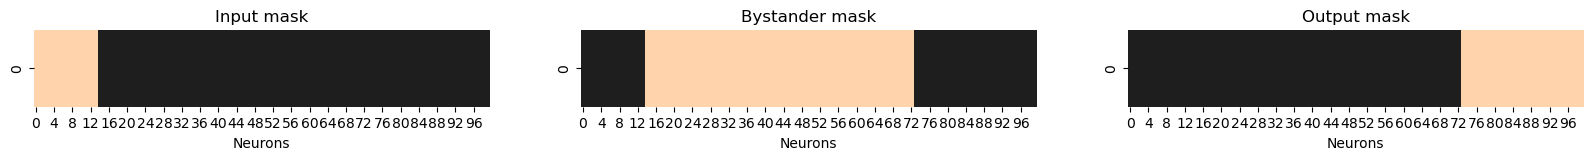

In [8]:
f, ax = plt.subplots(1, 3, figsize=(20, 1))
sns.heatmap(masks['input_weight_mask'][np.newaxis], ax=ax[0], square=False, center=0, cbar=False)
ax[0].set_title('Input mask')
ax[0].set_xlabel('Neurons')
sns.heatmap(masks['bystanders'][np.newaxis], ax=ax[1], square=False, center=0, cbar=False)
ax[1].set_title('Bystander mask')
ax[1].set_xlabel('Neurons')
sns.heatmap(masks['output_weight_mask'][np.newaxis], ax=ax[2], square=False, center=0, cbar=False)
ax[2].set_title('Output mask')
ax[2].set_xlabel('Neurons')
plt.show()

In [9]:
mask_labels = ['input_input', 'bystanders_bystanders', 'output_output',
               'input_output', 'output_input',
               'input_bystanders', 'bystanders_input',
               'output_bystanders', 'bystanders_output']
n_masks = len(mask_labels)

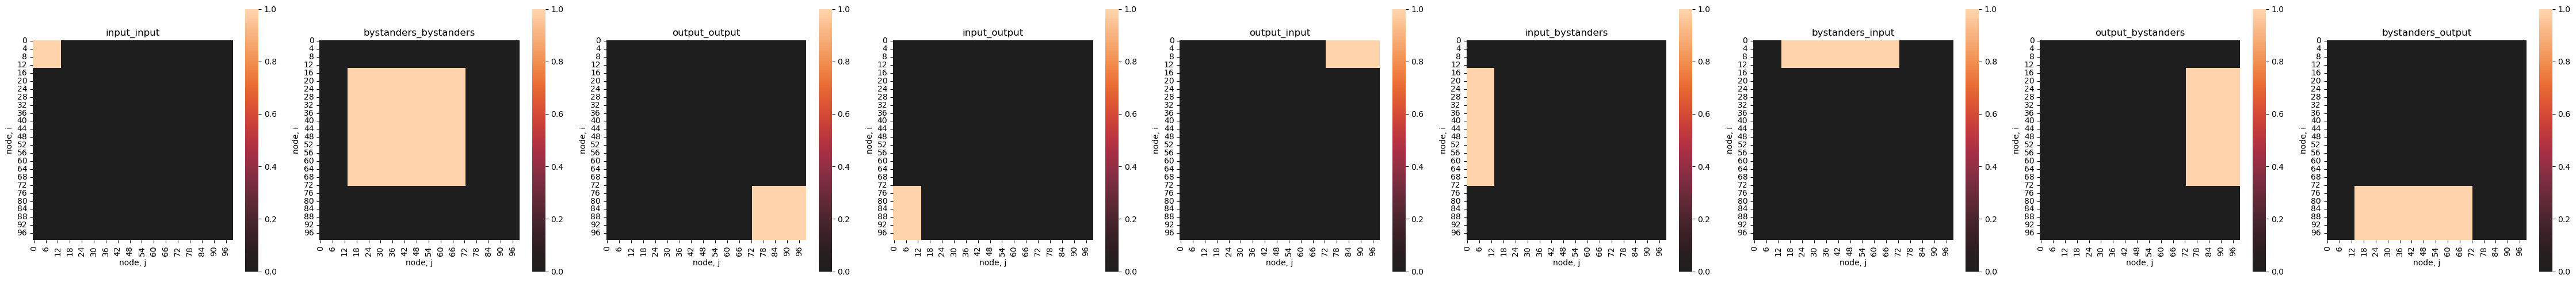

In [10]:
f, ax = plt.subplots(1, n_masks, figsize=(n_masks*5, 5))
for i, mask in enumerate(mask_labels):
    sns.heatmap(masks[mask], ax=ax[i], square=True, center=0)
    ax[i].set_title(mask)
    ax[i].set_xlabel('node, j')
    ax[i].set_ylabel('node, i')
f.tight_layout()
plt.show()

Setup regularization kernel

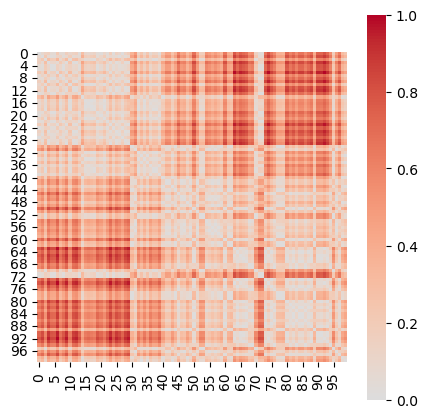

In [11]:
# setup regularization kernel
if kernel_type is None:
    # no distance penalty
    regularization_kernel = None
elif kernel_type == 'euclidean':
    # static distance matrix for regularization
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    centroids = centroids[:hidden_size]
    centroids.set_index("ROI Name", inplace=True)
    distance_matrix = distance.pdist(centroids, "euclidean")  # get euclidean distances between nodes
    distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix
    regularization_kernel = normalize_x(distance_matrix)
elif kernel_type == 'sa_axis':
    sa_axis = np.load(os.path.join(datadir, 'schaefer{0}_sa-axis.npy'.format(hidden_size * 2)))
    sa_axis = sa_axis[:hidden_size]
    n = len(sa_axis)
    distance_matrix = np.zeros((n, n))
    for i in np.arange(n):
        for j in np.arange(n):
            distance_matrix[i, j] = sa_axis[i] - sa_axis[j]
    distance_matrix = np.abs(distance_matrix)
    regularization_kernel = normalize_x(distance_matrix)

if regularization_kernel is None:
    pass
elif regularization_kernel.ndim == 2:
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.heatmap(regularization_kernel, ax=ax, square=True, cmap='coolwarm', center=0)
    plt.show()
elif regularization_kernel.ndim == 3:
    f, ax = plt.subplots(1, 4, figsize=(20, 5))
    sns.heatmap(regularization_kernel[:, :, 0], ax=ax[0], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[0].set_title('Epoch 0')
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.33)], ax=ax[1], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[1].set_title('Epoch {0}'.format(int(n_epochs*.33)))
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.66)], ax=ax[2], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[2].set_title('Epoch {0}'.format(int(n_epochs*.66)))
    sns.heatmap(regularization_kernel[:, :, -1], ax=ax[3], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[3].set_title('Epoch {0}'.format(int(n_epochs)))
plt.show()

Train model

In [12]:
run = 0
random.seed(run)
np.random.seed(run)
torch.manual_seed(run)
torch.cuda.manual_seed(run)
torch.cuda.manual_seed_all(run)

In [13]:
# setup weight masks
if mask_weights:
    input_weight_mask = masks['input_weight_mask']
    output_weight_mask = masks['output_weight_mask']
else:
    input_weight_mask = None
    output_weight_mask = None
    print(input_weight_mask, output_weight_mask)

In [14]:
# Instantiate the network and print information
model = RNNNet(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes, dt=dataset.env.dt,
               regularization_kernel=regularization_kernel, input_weight_mask=input_weight_mask, output_weight_mask=output_weight_mask)
print(model)

# Use Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

running_loss = 0
running_acc = 0
for i in range(1000):
    inputs, labels = dataset()
    inputs = torch.from_numpy(inputs).type(torch.float)
    labels = torch.from_numpy(labels.flatten()).type(torch.long)

    # in your training loop:
    optimizer.zero_grad()   # zero the gradient buffers
    output, _ = model(inputs)
    output = output.view(-1, num_classes)
    loss = criterion(output, labels)

    # perform regularization
    if model.regularization_kernel is None:
        reg = reg_weight * model.regularization(model.rnn.h2h.weight, type=reg_type)
    else:
        reg = reg_weight * model.regularization(model.rnn.h2h.weight, type=reg_type, matrix=model.regularization_kernel)

    # add regularization component
    loss += reg

    loss.backward()
    optimizer.step()    # Does the update

    running_loss += loss.item()
    if i % 100 == 99:
        running_loss /= 100
        print('Step {}, Loss {:0.4f}'.format(i+1, running_loss))
        running_loss = 0

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=3, out_features=100, bias=True)
    (h2h): Linear(in_features=100, out_features=100, bias=True)
  )
  (fc): Linear(in_features=100, out_features=3, bias=True)
)
Step 100, Loss 0.3779
Step 200, Loss 0.3072
Step 300, Loss 0.2234
Step 400, Loss 0.1680
Step 500, Loss 0.1361
Step 600, Loss 0.2699
Step 700, Loss 0.3051
Step 800, Loss 0.2607
Step 900, Loss 0.2072
Step 1000, Loss 0.2458


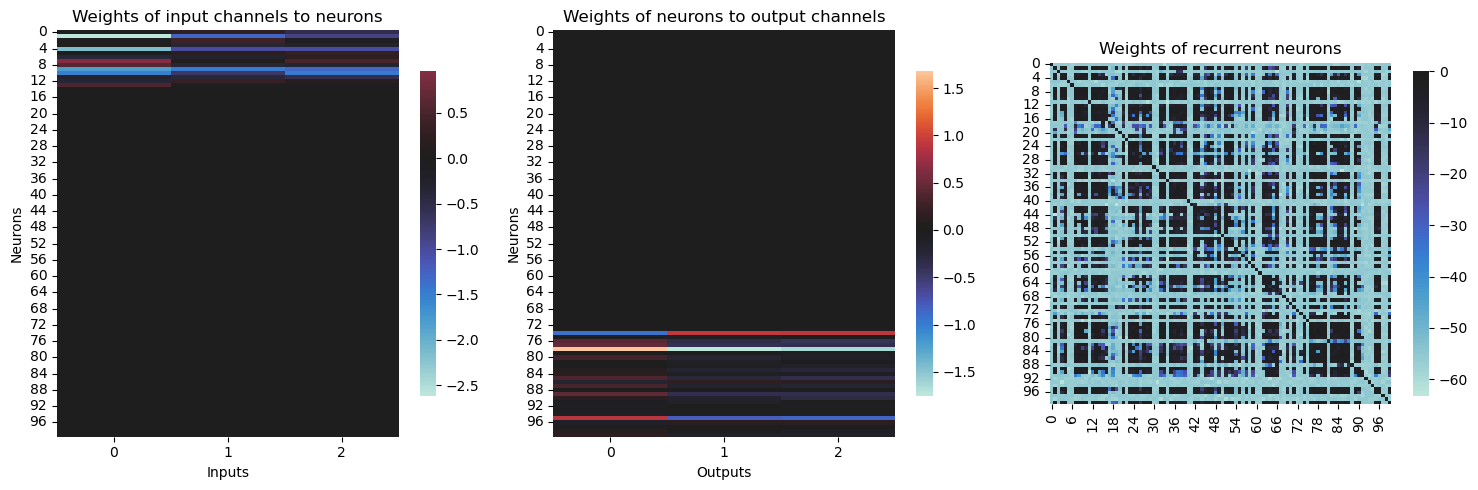

In [15]:
f, ax = plt.subplots(1, 3, figsize=(15, 5))

# input weights
sns.heatmap(model.rnn.input2h.weight.detach().cpu().numpy(), ax=ax[0], square=False, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[0].set_title('Weights of input channels to neurons')
ax[0].set_xlabel('Inputs')
ax[0].set_ylabel('Neurons')

# output weights
sns.heatmap(model.fc.weight.detach().cpu().numpy().T, ax=ax[1], square=False, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[1].set_title('Weights of neurons to output channels')
ax[1].set_xlabel('Outputs')
ax[1].set_ylabel('Neurons')

# hidden weights
h_weights = model.rnn.h2h.weight.detach().cpu().numpy()
sns.heatmap(np.log(np.abs(h_weights)), ax=ax[2], square=True, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[2].set_title('Weights of recurrent neurons')

f.tight_layout()
plt.show()

In [16]:
import numpy as np
dataset.env.reset(no_step=True)
perf = 0
n_trials = 100
activity_dict = {}
info = {}
for i in range(n_trials):
    dataset.env.new_trial()
    ob, gt = dataset.env.ob, dataset.env.gt
    inputs = torch.from_numpy(ob[:, np.newaxis, :]).type(torch.float)
    action_pred, rnn_activity = model(inputs)
    rnn_activity = rnn_activity[:, 0, :].detach().numpy()
    activity_dict[i] = rnn_activity
    info[i] = dataset.env.trial

# Concatenate activity for PCA
activity = np.concatenate(list(activity_dict[i] for i in range(n_trials)), axis=0)
print('Shape of the neural activity: (Time points, Neurons): ', activity.shape)

# Print trial information
for i in range(5):
    print('Trial ', i, info[i])

Shape of the neural activity: (Time points, Neurons):  (2400, 100)
Trial  0 {'ground_truth': 1, 'coh': 25.6}
Trial  1 {'ground_truth': 1, 'coh': 12.8}
Trial  2 {'ground_truth': 1, 'coh': 12.8}
Trial  3 {'ground_truth': 1, 'coh': 12.8}
Trial  4 {'ground_truth': 1, 'coh': 25.6}


In [17]:
# Compute PCA and visualize
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(activity)
# print('Shape of the projected activity: (Time points, PCs): ', activity_pc.shape)

PCA(n_components=2)

Text(0, 0.5, 'PC 2')

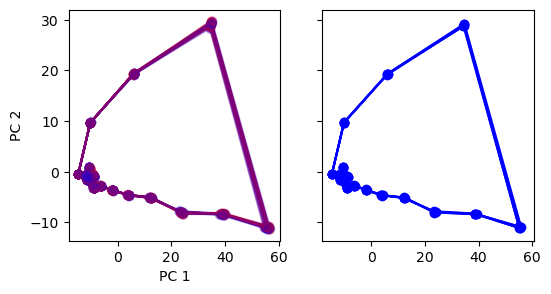

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(6, 3))
for i in range(n_trials):
    activity_pc = pca.transform(activity_dict[i])
    trial = info[i]
    color = 'red' if trial['ground_truth'] == 0 else 'blue'
    _ = ax1.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color, alpha=0.1)

    if i < 5:
        _ = ax2.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')

In [19]:
# Freeze for parameters in the recurrent network
for param in model.parameters():
    param.requires_grad = False

batch_size = 64

# Inputs should be the 0-coherence mean input during stimulus period
# This will be task-specific
input = np.tile([1, 0.5, 0.5], (batch_size, 1))
input = torch.tensor(input, dtype=torch.float32)

# Here hidden activity is the variable to be optimized
# Initialized randomly for search in parallel (activity all positive)
hidden = torch.tensor(np.random.rand(batch_size, hidden_size)*3,
                      requires_grad=True, dtype=torch.float32)

# Use Adam optimizer
optimizer = torch.optim.Adam([hidden], lr=0.001)
criterion = nn.MSELoss()

running_loss = 0
for i in range(10000):
    optimizer.zero_grad()   # zero the gradient buffers

    # Take the one-step recurrent function from the trained network
    new_h = model.rnn.recurrence(input, hidden)
    loss = criterion(new_h, hidden)
    loss.backward()
    optimizer.step()    # Does the update

    running_loss += loss.item()
    if i % 1000 == 999:
        running_loss /= 1000
        print('Step {}, Loss {:0.4f}'.format(i+1, running_loss))
        running_loss = 0

Step 1000, Loss 4.1545
Step 2000, Loss 1.0585
Step 3000, Loss 0.3712
Step 4000, Loss 0.1604
Step 5000, Loss 0.0726
Step 6000, Loss 0.0286
Step 7000, Loss 0.0076
Step 8000, Loss 0.0014
Step 9000, Loss 0.0003
Step 10000, Loss 0.0001


(64, 100)


Text(0, 0.5, 'PC 2')

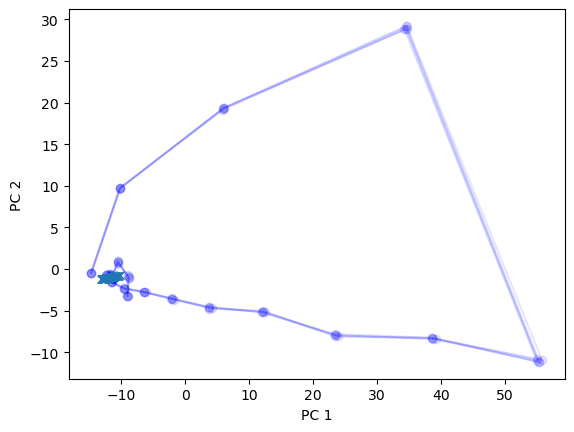

In [20]:
fixedpoints = hidden.detach().numpy()
print(fixedpoints.shape)

# Plot in the same space as activity
plt.figure()
for i in range(5):
    activity_pc = pca.transform(activity_dict[i])
    trial = info[i]
    color = 'red' if trial['ground_truth'] == 0 else 'blue'
    plt.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-',
             color=color, alpha=0.1)

# Fixed points are shown in cross
fixedpoints_pc = pca.transform(fixedpoints)
plt.plot(fixedpoints_pc[:, 0], fixedpoints_pc[:, 1], 'x')

plt.xlabel('PC 1')
plt.ylabel('PC 2')